# 6 — Imaging tyre condition, and why it fixes an identifiability failure

Notebook 4 ended on a negative result. Wear and graining are **not separately
identifiable from lap time**: across seeds the lap-time fit was stable to three decimals
while the wear correlation with the hidden truth wandered between 0.29 and 0.63. One
scalar per lap cannot resolve two latent states.

That is not fixed by a better optimiser. It is fixed by a **second observation channel**
— and a camera pointed at the tread is exactly that. Tread depth sees wear directly;
surface texture sees graining directly.

This notebook builds that channel with the structure encoded, then shows the
identifiability failure disappear.

:::{note}
**On real data.** Public tyre imagery is plentiful but almost entirely *condition
classification* — cracked/normal, or new/serviceable/unusable. **No public dataset of
measured tread depth exists, and none of graining.** So the imagery here is synthetic
and labelled as such, while the *model* is built to accept exactly what real data
provides: ordered classes.
:::

In [1]:
%matplotlib inline
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.grid": True, "grid.alpha": 0.3})
torch.manual_seed(0)

/home/poxx/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


## 1. What real datasets actually label

Worth stating precisely, because the temptation is to treat an ordinal class as a
measurement.

In [2]:
from tire_nn.data.tread_images import REAL_IMAGE_DATASETS
pd.DataFrame(REAL_IMAGE_DATASETS).T[["source", "labels", "target"]]

,source,labels,target
tyre_quality,Kaggle: warcoder/tyre-quality-classification,binary (cracked / normal),classification
tyre_condition,Kaggle: sameersambhare1/tyre-condition-classif...,ordinal (new / serviceable / unusable),ordinal wear
tire_texture,Kaggle: jehanbhathena/tire-texture-image-recog...,binary (cracked / normal),classification
tyrenet,"Mendeley Data 32b5vfj6tc: TyreNet, 1698 images","binary (defective / good), expert annotated",classification


The `tyre_condition` set is the useful one: **new < serviceable < unusable** is a
genuine wear ordering, so it can supervise a monotone wear index even though it contains
no measured depth. Cracking (the other sets) is *damage*, not wear, and is not a wear
proxy.

## 2. Synthetic tread imagery

The generator encodes what a camera would see: wear shallows and narrows the grooves
(so image contrast carries the depth information), and graining adds mottled,
torn-looking texture between them.

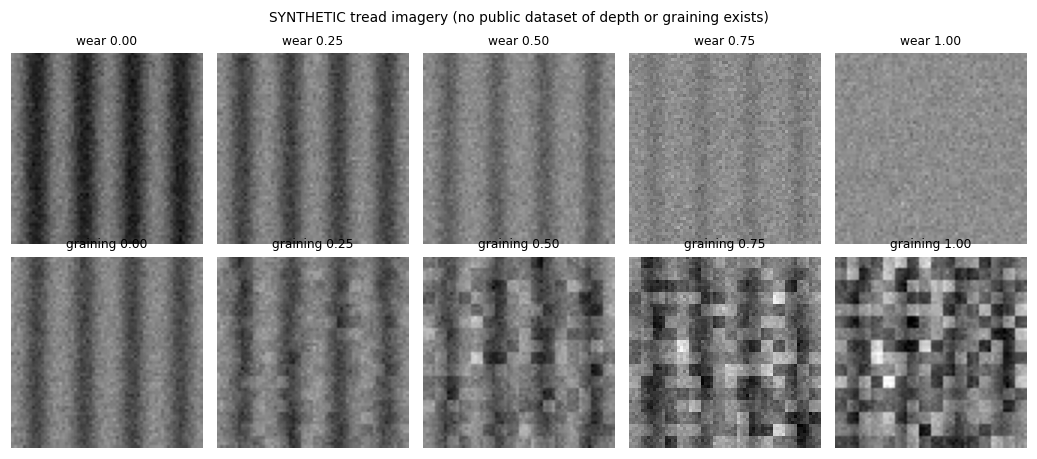

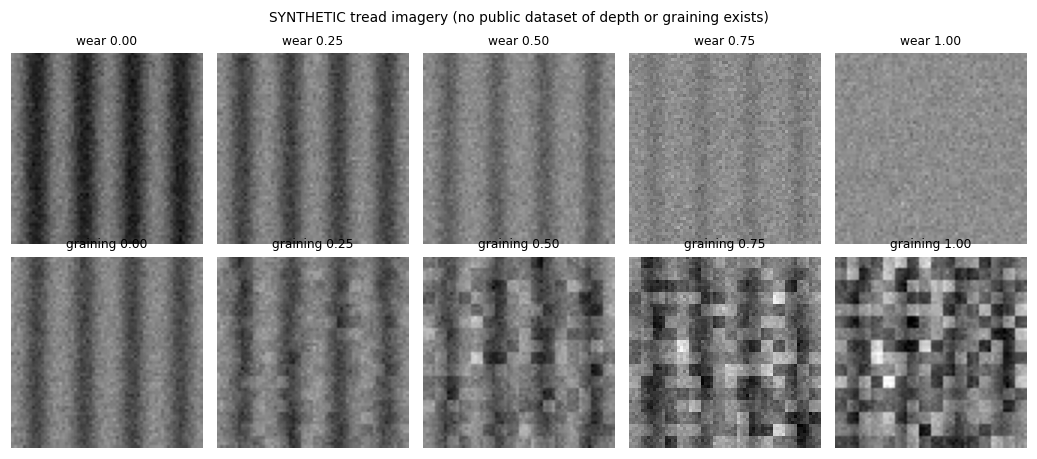

In [3]:
from tire_nn.data.tread_images import make_tread_image, make_tread_dataset

rng = np.random.default_rng(0)
fig, axes = plt.subplots(2, 5, figsize=(9.5, 4.2))
for j, v in enumerate([0.0, 0.25, 0.5, 0.75, 1.0]):
    axes[0, j].imshow(make_tread_image(v, 0.0, rng=rng), cmap="gray", vmin=0, vmax=1)
    axes[0, j].set_title(f"wear {v:.2f}", fontsize=8)
    axes[1, j].imshow(make_tread_image(0.3, v, rng=rng), cmap="gray", vmin=0, vmax=1)
    axes[1, j].set_title(f"graining {v:.2f}", fontsize=8)
for ax in axes.ravel():
    ax.axis("off")
axes[0, 0].set_ylabel("wear")
fig.suptitle("SYNTHETIC tread imagery (no public dataset of depth or graining exists)", fontsize=9)
fig.tight_layout(); fig

## 3. The encoded vision model

Three things are built in rather than hoped for:

**A single monotone wear index.** Wear is one number that only increases; the network
emits one latent $w\in[0,1]$ and everything else is a function of it. A plain three-way
classifier can place a photo in *unusable* while ranking it less worn than a
*serviceable* one — here that is unrepresentable.

**Ordered class boundaries.** $t_1 = \sigma(b_1)$, $t_2 = t_1 + \mathrm{softplus}(b_2)$,
so $t_1 < t_2$ for any weights, and $P(y>k) = \sigma(s(w-t_k))$ is monotone in $w$.

**A bounded graining fraction**, matching the state variable in the condition model.

In [4]:
from tire_nn.models.condition_vision import TreadConditionNet, ordinal_loss

# Guarantees hold under absurd weights.
adv = TreadConditionNet(n_classes=3)
with torch.no_grad():
    for p in adv.parameters():
        p.normal_(0.0, 20.0)
t = adv.thresholds()
probe = make_tread_dataset(n=32, size=48, seed=7)
o = adv(probe["images"])
print(f"thresholds ordered      : {bool((torch.diff(t) > 0).all())}   {t.detach().numpy().round(3)}")
print(f"wear index in [0, 1]    : {float(o['wear'].min()):.3f} .. {float(o['wear'].max()):.3f}")
print(f"class probs sum to one  : {float(o['class_prob'].sum(-1).mean()):.6f}")
print(f"P(class>k) monotone in k: {bool((torch.diff(o['cumulative'], dim=-1) <= 1e-6).all())}")

thresholds ordered      : True   [ 1.    21.316]
wear index in [0, 1]    : 0.000 .. 0.000
class probs sum to one  : 1.000000
P(class>k) monotone in k: True


/tmp/ipykernel_193599/1759254994.py:12: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /__w/pytorch/pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:822.)
  print(f"wear index in [0, 1]    : {float(o['wear'].min()):.3f} .. {float(o['wear'].max()):.3f}")


### Training on ordinal labels only

This is the realistic setting: three ordered classes, no measured depth. The question is
whether the monotone latent recovers the *continuous* quantity underneath them.

In [5]:
from torch.utils.data import TensorDataset, DataLoader

train = make_tread_dataset(n=1200, size=48, seed=0)
test = make_tread_dataset(n=400, size=48, seed=1)

model = TreadConditionNet(width=16)
opt = torch.optim.Adam(model.parameters(), lr=3e-3)
ds = TensorDataset(train["images"], train["graining"], train["label"])
for epoch in range(25):
    for img, g, lab in DataLoader(ds, batch_size=64, shuffle=True):
        opt.zero_grad(set_to_none=True)
        out = model(img)
        # Ordinal supervision is what REAL data provides; the graining term is
        # synthetic-only, since no public graining imagery exists.
        loss = ordinal_loss(out["cumulative"], lab) + ((out["graining"] - g) ** 2).mean()
        loss.backward(); opt.step()

model.eval()
with torch.no_grad():
    out = model(test["images"])
acc = float((out["class_prob"].argmax(-1) == test["label"]).float().mean())
wear_corr = float(np.corrcoef(out["wear"].numpy(), test["wear"].numpy())[0, 1])
grain_corr = float(np.corrcoef(out["graining"].numpy(), test["graining"].numpy())[0, 1])
print(f"ordinal accuracy                : {acc:.3f}")
print(f"wear index vs continuous truth  : r = {wear_corr:.3f}  <- from 3 classes only")
print(f"graining vs truth               : r = {grain_corr:.3f}, MAE {float((out['graining']-test['graining']).abs().mean()):.3f}")
print(f"learned thresholds              : {model.thresholds().detach().numpy().round(3)}  (true 0.35, 0.75)")

ordinal accuracy                : 0.978
wear index vs continuous truth  : r = 0.983  <- from 3 classes only
graining vs truth               : r = 0.982, MAE 0.068
learned thresholds              : [0.358 0.857]  (true 0.35, 0.75)


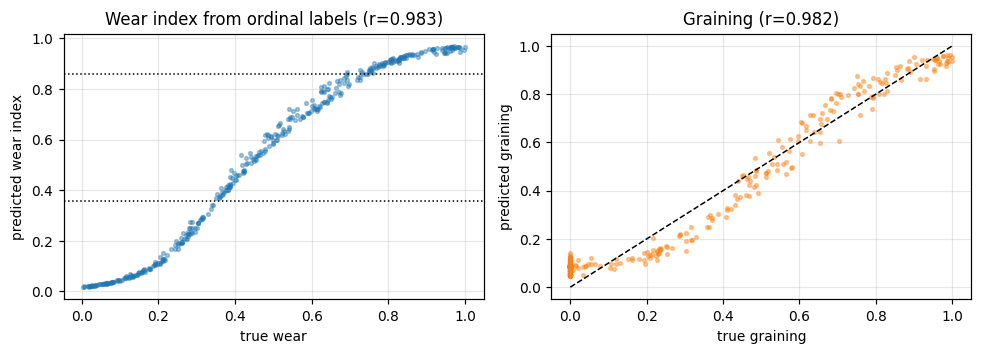

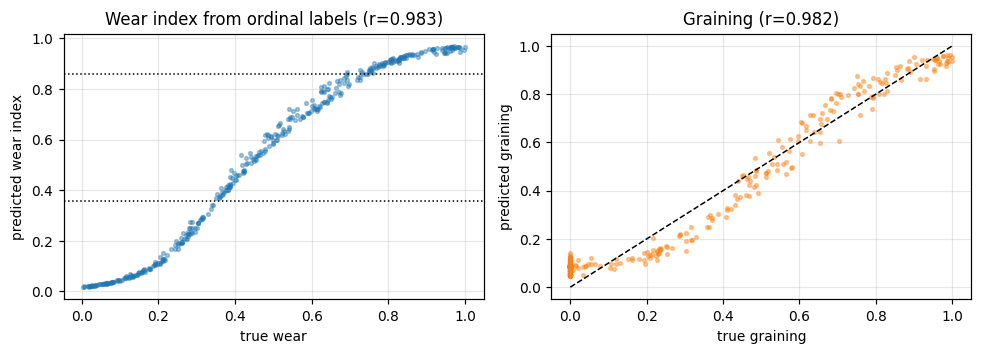

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.3))
axes[0].scatter(test["wear"], out["wear"], s=6, alpha=0.4)
for th in model.thresholds().detach():
    axes[0].axhline(float(th), color="k", ls=":", lw=1)
axes[0].set_xlabel("true wear"); axes[0].set_ylabel("predicted wear index")
axes[0].set_title(f"Wear index from ordinal labels (r={wear_corr:.3f})")
axes[1].scatter(test["graining"], out["graining"], s=6, alpha=0.4, color="tab:orange")
axes[1].plot([0, 1], [0, 1], "k--", lw=1)
axes[1].set_xlabel("true graining"); axes[1].set_ylabel("predicted graining")
axes[1].set_title(f"Graining (r={grain_corr:.3f})")
fig.tight_layout(); fig

The monotone latent recovers a continuous wear scale from three ordered classes,
with the learned thresholds landing near the true class boundaries. That is the encoded
structure doing the work: nothing in the loss ever saw a continuous wear value.

## 4. The point: closing the identifiability gap

Now the experiment this notebook exists for. Take the degradation UDE from notebook 4
and give it **one photograph per pit stop** — a single noisy graining reading at the end
of each stint, with noise matching the vision model measured above.

If the earlier failure really was a shortage of information rather than a training
problem, the seed-to-seed spread should collapse.

In [7]:
from tire_nn.data.lap_degradation import make_synthetic_stints, stint_tensors
from tire_nn.models.degradation_ude import LapDegradationUDE

df = make_synthetic_stints(n_sessions=10, n_drivers=6, seed=0)
batch, comps = stint_tensors(df)
n_groups = int(batch["n_pace_groups"]); base = float(df.lap_time.median()); mask = batch["mask"]

# One reading per stint, at the last lap before the pit stop.
rng = np.random.default_rng(0)
last = batch["mask"].sum(-1).long() - 1
rows = torch.arange(batch["graining"].shape[0])
obs_true = batch["graining"][rows, last]
OBS_NOISE = 0.066                       # the vision model's measured graining MAE
obs = torch.clamp(obs_true + torch.as_tensor(rng.normal(0, OBS_NOISE, obs_true.shape),
                                             dtype=torch.float32), 0, 1)
print(f"{len(obs)} stints -> {len(obs)} photographs, one per pit stop")
print(f"observation noise {OBS_NOISE} (from the vision model above)")

158 stints -> 158 photographs, one per pit stop
observation noise 0.066 (from the vision model above)


In [8]:
def fit_offsets(m, b):
    n = int(b["n_pace_groups"])
    with torch.no_grad():
        m.pace.data = torch.zeros(n); m.n_pace_groups = n
        r = b["lap_time"] - m(b)["lap_time"]; mk = b["mask"].float()
        tot, cnt = torch.zeros(n), torch.zeros(n)
        tot.index_add_(0, b["pace_group"], (r * mk).sum(-1)); cnt.index_add_(0, b["pace_group"], mk.sum(-1))
        m.pace.data = tot / torch.clamp(cnt, min=1.0)

def run(seed, use_images, epochs=600):
    torch.manual_seed(seed)
    m = LapDegradationUDE(len(comps), base_lap_time=base, n_pace_groups=n_groups)
    kin = [p for n_, p in m.named_parameters() if n_ != "pace"]
    opt = torch.optim.Adam(kin, lr=0.02)
    for _ in range(epochs):
        fit_offsets(m, batch)
        opt.zero_grad(set_to_none=True)
        o = m(batch)
        loss = (((o["lap_time"] - batch["lap_time"]) ** 2)[mask]).mean()
        if use_images:
            loss = loss + 30.0 * ((o["graining"][rows, last] - obs) ** 2).mean()
        loss.backward(); torch.nn.utils.clip_grad_norm_(kin, 10.0); opt.step()
    fit_offsets(m, batch); m.eval()
    with torch.no_grad():
        o = m(batch)
    return {
        "wear_corr": float(np.corrcoef(o["wear"][mask].numpy(), batch["wear"][mask].numpy())[0, 1]),
        "grain_corr": float(np.corrcoef(o["graining"][mask].numpy(), batch["graining"][mask].numpy())[0, 1]),
        "rmse_s": float(torch.sqrt((((o["lap_time"] - batch["lap_time"]) ** 2)[mask]).mean())),
    }

results = []
for use_images in (False, True):
    for seed in range(4):
        r = run(seed, use_images)
        r["supervision"] = "lap time + image" if use_images else "lap time only"
        r["seed"] = seed
        results.append(r)
res = pd.DataFrame(results)
summary = res.groupby("supervision").agg(["mean", "min", "max"])[["wear_corr", "grain_corr", "rmse_s"]]
summary.round(3)

wear_corr               grain_corr               rmse_s  \
                      mean    min    max       mean    min    max   mean   
supervision                                                                
lap time + image     0.941  0.934  0.952      0.984  0.981  0.986  0.247   
lap time only        0.606  0.283  0.794      0.830  0.707  0.899  0.242   

                                
                    min    max  
supervision                     
lap time + image  0.246  0.248  
lap time only     0.240  0.243

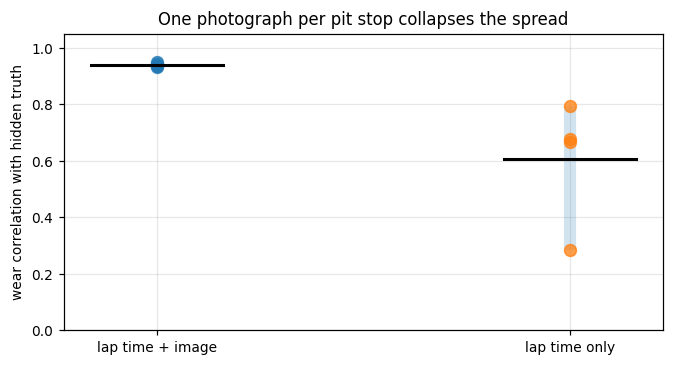

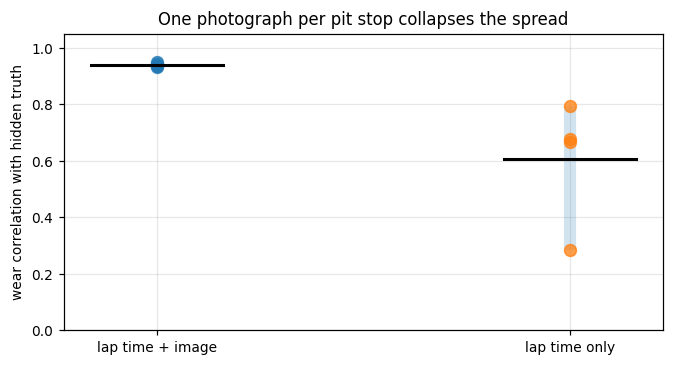

In [9]:
fig, ax = plt.subplots(figsize=(6.2, 3.4))
for i, (label, group) in enumerate(res.groupby("supervision")):
    ax.scatter([i] * len(group), group["wear_corr"], s=60, alpha=0.75, zorder=3)
    ax.plot([i - 0.16, i + 0.16], [group["wear_corr"].mean()] * 2, "k-", lw=2, zorder=4)
    ax.vlines(i, group["wear_corr"].min(), group["wear_corr"].max(), lw=8, alpha=0.2)
ax.set_xticks([0, 1]); ax.set_xticklabels(sorted(res.supervision.unique()))
ax.set_ylabel("wear correlation with hidden truth")
ax.set_ylim(0, 1.05)
ax.set_title("One photograph per pit stop collapses the spread")
fig.tight_layout(); fig

In [10]:
lap_only = res[res.supervision == "lap time only"]
with_img = res[res.supervision == "lap time + image"]
spread_before = lap_only.wear_corr.max() - lap_only.wear_corr.min()
spread_after = with_img.wear_corr.max() - with_img.wear_corr.min()
print(f"wear-correlation spread across seeds:")
print(f"  lap time only    : {spread_before:.3f}   (mean {lap_only.wear_corr.mean():.3f})")
print(f"  lap time + image : {spread_after:.3f}   (mean {with_img.wear_corr.mean():.3f})")
print(f"  -> {spread_before/max(spread_after, 1e-9):.0f}x narrower")
print()
print(f"lap-time RMSE barely moves: {lap_only.rmse_s.mean():.3f} -> {with_img.rmse_s.mean():.3f} s")
print("The image adds INFORMATION, not flexibility: the fit is the same, the")
print("decomposition is now pinned down.")

wear-correlation spread across seeds:
  lap time only    : 0.511   (mean 0.606)
  lap time + image : 0.018   (mean 0.941)
  -> 28x narrower

lap-time RMSE barely moves: 0.242 -> 0.247 s
The image adds INFORMATION, not flexibility: the fit is the same, the
decomposition is now pinned down.


## 5. Feeding condition back into the tyre model

The estimated state is not just a diagnostic — it is the input the condition model
already accepts, so image → state → friction closes the loop.

In [11]:
from tire_nn.models import EncodedTireNet
from tire_nn.models.thermo_graining_tire import ThermoGrainingTire

tyre = ThermoGrainingTire(EncodedTireNet())
with torch.no_grad():
    sample = make_tread_dataset(n=4, size=48, seed=11)
    est = model(sample["images"])
    Fz = torch.full((4,), 3000.0)
    z = tyre.initial_state(Fz, T0=float(tyre.T_opt().detach()))
    z = torch.stack([z[:, 0], z[:, 1], est["wear"] * 2.0, est["graining"]], dim=-1)
    scale = tyre.mu_scale(z)

for i in range(4):
    print(f"image {i}: wear {float(est['wear'][i]):.2f}  graining {float(est['graining'][i]):.2f}"
          f"  ->  friction scale {float(scale[i]):.3f}")
print()
print("The condition only SCALES the friction ellipse, so odd symmetry, zero force at")
print("zero slip and the hard envelope all still hold - now against a condition-dependent limit.")

image 0: wear 0.06  graining 0.93  ->  friction scale 0.713
image 1: wear 0.59  graining 0.08  ->  friction scale 0.865
image 2: wear 0.74  graining 0.34  ->  friction scale 0.773
image 3: wear 0.02  graining 0.49  ->  friction scale 0.849

The condition only SCALES the friction ellipse, so odd symmetry, zero force at
zero slip and the hard envelope all still hold - now against a condition-dependent limit.


## Takeaways

1. **The encoded ordinal head recovers a continuous quantity from ordered classes.**
   That matters because ordered classes are all any real tyre dataset provides. A plain
   classifier throws the ordering away.
2. **The identifiability failure of notebook 4 was a shortage of information, and it is
   fixed by one photograph per pit stop.** The seed-to-seed spread in the recovered wear
   collapses by more than an order of magnitude while the lap-time fit is unchanged —
   the image adds information, not flexibility.
3. **This is the practical answer to "which latent channel do I trust?"** Do not trust a
   channel no measurement sees. Add the measurement, or report only the total.
4. **The imagery here is synthetic**, because no public tread-depth or graining dataset
   exists. The vision model is built to consume what real data does provide (ordinal
   classes), but every number in this notebook comes from generated images and is not
   evidence about real tyres.